El objetivo es analizar los resultado utilizando etiquetas categoricas y one-hot-encoding para el dataset CIFAR-10

Se vera ejemplos de API Secuencial y API Funcional el cual nos permite disenar una arquitectura

##**CNN CON DATASET CIFAR 10 (ETIQUETAS CATEGÓRICAS)**

In [1]:
# SOLO PARA USO EN GOOGLE COLABORATORY
# Para conectar el notebook con la cuenta de gdrive
from google.colab import drive
drive.mount('/content/drive/')



Mounted at /content/drive/


In [2]:
BASE_FOLDER = '/content/drive/MyDrive/Colab Notebooks/ML/DeepLearning/' # Ajustar el directorio raíz de Google Drive

#### **- Cargando el conjunto de datos**

In [4]:
# Importando el set de datos CIFAR10
from tensorflow.keras.datasets import cifar10

((trainX, trainY), (testX, testY)) = cifar10.load_data()
labelNames = ["Avión", "Automóvil", "Pájaro", "Gato", "Ciervo", "Perro", "Rana", "Caballo", "Barco", "Camión"]



In [5]:
print("Configuration del dataset train:")
print(trainX.shape)
print(trainY.shape)
print("Configuration del dataset test:")
print(testX.shape)
print(testY.shape)

Configuration del dataset train:
(50000, 32, 32, 3)
(50000, 1)
Configuration del dataset test:
(10000, 32, 32, 3)
(10000, 1)


Dataset de train 50000 modelos de talla 32*32 a color

Dataset de test 10000 modelos de talla 32*32 a color



#### **- Inspeccionando el conjunto de datos TRAIN**

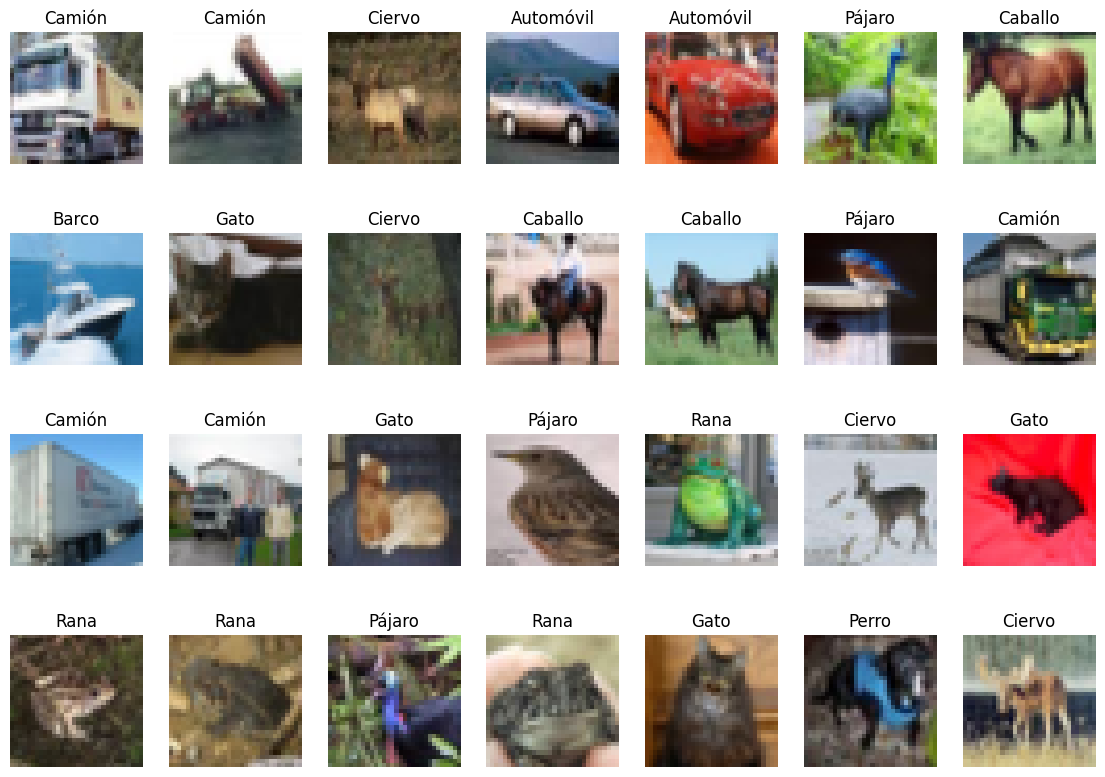

In [7]:
import matplotlib.pyplot as plt
fig = plt.figure(figsize=(14,10))
for n in range(1, 29):
    fig.add_subplot(4, 7, n)
    img = trainX[n]
    plt.imshow(img)
    plt.title(labelNames[trainY[n][0]])
    plt.axis('off')

#### **- Acondicionando el conjunto de datos**

In [9]:
# PREPROCESAMIENTO DE LOS DATOS

#normalizando imagenes
trainX = trainX / 255.0
testX = testX / 255.0

# Por si es necesario convertir etiquetas a one-hot encoding
#from sklearn.preprocessing import LabelBinarizer
#lb = LabelBinarizer()
#trainY = lb.fit_transform(trainY)
#testY = lb.transform(testY)

#### **- Creando la topología de red neuronal y entrenándola: MLP**

In [10]:
# Imports necesarios
import numpy as np
from sklearn.metrics import classification_report
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Dropout
from tensorflow.keras.optimizers import SGD
import matplotlib.pyplot as plt

# Arquitectura de red
# Definimos el modo API Sequential
model = Sequential()

model.add(Flatten())
model.add(Dense(2048, input_shape=(3072,), activation="relu")) # input_shape = 32 x 32 x 3 = 3072
#model.add(Dropout(0.5))
model.add(Dense(1024, activation="relu"))
#model.add(Dropout(0.5))
model.add(Dense(512, activation="relu"))
#model.add(Dropout(0.5))
model.add(Dense(128, activation="relu"))
#model.add(Dropout(0.5))
model.add(Dense(32, activation="relu"))
model.add(Dense(10, activation="softmax"))

# Compilamos el modelo y entrenamos
print("[INFO]: Entrenando red neuronal...")
# Compilamos el modelo
model.compile(loss="sparse_categorical_crossentropy", optimizer=SGD(0.01), metrics=["accuracy"]) # Etiquetas en decimal
# model.compile(loss="categorical_crossentropy", optimizer=SGD(0.01), metrics=["accuracy"]) # Etiquetas en one hot encoding





[INFO]: Entrenando red neuronal...


In [11]:
# Entrenamos el perceptrón multicapa
H = model.fit(trainX, trainY, validation_split=0.2, epochs=50, batch_size=32)


Epoch 1/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.3082 - loss: 1.9249 - val_accuracy: 0.3492 - val_loss: 1.8236
Epoch 2/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.3941 - loss: 1.6969 - val_accuracy: 0.3979 - val_loss: 1.6820
Epoch 3/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.4311 - loss: 1.6013 - val_accuracy: 0.4298 - val_loss: 1.5905
Epoch 4/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.4539 - loss: 1.5340 - val_accuracy: 0.4507 - val_loss: 1.5487
Epoch 5/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.4730 - loss: 1.4735 - val_accuracy: 0.4491 - val_loss: 1.5478
Epoch 6/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.4904 - loss: 1.4306 - val_accuracy: 0.4850 - val_loss: 1.4538
Epoch 7/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.5052 - loss: 1.3852 - val_accuracy: 0.4329 - val_loss: 1.5931
Epoch 8/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.5196 - loss: 1.3477 -

In [12]:
# Evaluamos con las muestras de test
print("[INFO]: Evaluando modelo...")

# Efectuamos predicciones
predictions = model.predict(testX, batch_size=32)

# Obtenemos el report
print(classification_report(testY, predictions.argmax(axis=1), target_names=labelNames)) # Etiquetas en decimal
# print(classification_report(testY.argmax(axis=1), predictions.argmax(axis=1), target_names=labelNames)) # Etiquetas one hot encoding

[INFO]: Evaluando modelo...
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
              precision    recall  f1-score   support

       Avión       0.59      0.69      0.64      1000
   Automóvil       0.63      0.66      0.64      1000
      Pájaro       0.46      0.26      0.33      1000
        Gato       0.39      0.31      0.34      1000
      Ciervo       0.40      0.54      0.46      1000
       Perro       0.37      0.55      0.44      1000
        Rana       0.58      0.57      0.57      1000
     Caballo       0.64      0.52      0.58      1000
       Barco       0.72      0.57      0.63      1000
      Camión       0.57      0.56      0.57      1000

    accuracy                           0.52     10000
   macro avg       0.53      0.52      0.52     10000
weighted avg       0.53      0.52      0.52     10000



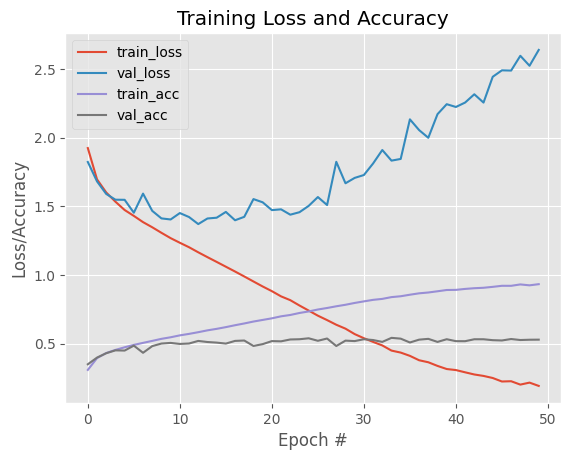

In [13]:
# Gráficas de evaluación durante el entrenamiento
plt.style.use("ggplot")
plt.figure()
plt.plot(np.arange(0, 50), H.history["loss"], label="train_loss")
plt.plot(np.arange(0, 50), H.history["val_loss"], label="val_loss")
plt.plot(np.arange(0, 50), H.history["accuracy"], label="train_acc")
plt.plot(np.arange(0, 50), H.history["val_accuracy"], label="val_acc")
plt.title("Training Loss and Accuracy")
plt.xlabel("Epoch #")
plt.ylabel("Loss/Accuracy")
plt.legend()

Resumen a creado un overfitting muy alto
con un accuracy bien bajo

#### **- Creando la topología de red neuronal y entrenándola: CNN**

In [14]:
# Import the necessary packages
import numpy as np
from tensorflow.keras import backend as K
from tensorflow.keras.layers import Input, Conv2D, Activation, Flatten, Dense, Dropout, BatchNormalization, MaxPooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import SGD, Adam
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt
from google.colab import drive

# Definimos entradas
# Modelo de API Functional , el nos da libertad de crear el modelo como queremos y no mas sequencial
inputs = Input(shape=(trainX.shape[1], trainX.shape[2], trainX.shape[3])) # shape=(32,32,3)

# BASE MODEL
# Primer set de capas CONV => RELU => CONV => RELU => POOL
x1 = Conv2D(32, (3, 3), padding="same", activation="relu")(inputs)
x1 = BatchNormalization()(x1)
x1 = Conv2D(32, (3, 3), padding="same", activation="relu")(x1)
x1 = BatchNormalization()(x1)
x1 = MaxPooling2D(pool_size=(2, 2))(x1)
x1 = Dropout(0.25)(x1)

# Segundo set de capas CONV => RELU => CONV => RELU => POOL
x2 = Conv2D(64, (3, 3), padding="same", activation="relu")(x1)
x2 = BatchNormalization()(x2)
x2 = Conv2D(64, (3, 3), padding="same", activation="relu")(x2)
x2 = BatchNormalization()(x2)
x2 = MaxPooling2D(pool_size=(2, 2))(x2)
x2 = Dropout(0.25)(x2)

# Tercer set de capas CONV => RELU => CONV => RELU => POOL
x3 = Conv2D(256, (3, 3), padding="same", activation="relu")(x2)
x3 = BatchNormalization()(x3)
x3 = Conv2D(256, (3, 3), padding="same", activation="relu")(x3)
x3 = BatchNormalization()(x3)
x3 = MaxPooling2D(pool_size=(2, 2))(x3)
x3 = Dropout(0.25)(x3)

# TOP MODEL
# Primer (y único) set de capas FC => RELU
xfc = Flatten()(x3)
xfc = Dense(512, activation="relu")(xfc)
xfc = BatchNormalization()(xfc)
xfc = Dropout(0.5)(xfc)

predictions = Dense(10, activation="softmax")(xfc)

# Unimos las entradas y el modelo mediante la función Model con parámetros inputs y ouputs
model_cnn = Model(inputs=inputs, outputs=predictions)

# Compilar el modelo
print("[INFO]: Compilando el modelo...")
model_cnn.compile(loss="sparse_categorical_crossentropy", optimizer=Adam(learning_rate=0.001), metrics=["accuracy"])


[INFO]: Compilando el modelo...


In [15]:

# Entrenamiento de la red
print("[INFO]: Entrenando la red...")
H = model_cnn.fit(trainX, trainY, validation_split=0.2, batch_size=128, epochs=50)

# Almaceno el modelo en Drive
# Montamos la unidad de Drive
drive.mount('/content/drive')
# Almacenamos el modelo empleando la función mdoel.save de Keras
model_cnn.save(BASE_FOLDER+"deepCNN_CIFAR10.h5")




[INFO]: Entrenando la red...
Epoch 1/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 34s 60ms/step - accuracy: 0.4560 - loss: 1.6407 - val_accuracy: 0.2189 - val_loss: 2.6421
Epoch 2/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 22ms/step - accuracy: 0.6360 - loss: 1.0355 - val_accuracy: 0.6692 - val_loss: 0.9734
Epoch 3/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 22ms/step - accuracy: 0.7025 - loss: 0.8398 - val_accuracy: 0.7062 - val_loss: 0.8586
Epoch 4/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 23ms/step - accuracy: 0.7430 - loss: 0.7306 - val_accuracy: 0.7516 - val_loss: 0.7114
Epoch 5/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 22ms/step - accuracy: 0.7710 - loss: 0.6537 - val_accuracy: 0.7454 - val_loss: 0.7546
Epoch 6/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 22ms/step - accuracy: 0.7968 - loss: 0.5844 - val_accuracy: 0.7984 - val_loss: 0.5761
Epoch 7/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 22ms/step - accuracy: 0.8179 - loss: 0.5217 - val_accuracy: 0.7924 - val_loss: 0.6196
Epoch 8/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 22ms/step - accuracy: 0.

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Evaluación del modelo
print("[INFO]: Evaluando el modelo...")
# Efectuamos la predicción (empleamos el mismo valor de batch_size que en training)
predictions = model_cnn.predict(testX, batch_size=128)

# Sacamos el report para test
print(classification_report(testY, predictions.argmax(axis=1), target_names=labelNames))

In [ ]:

# Gráficas de evaluación durante el entrenamiento
plt.style.use("ggplot")
plt.figure()
plt.plot(np.arange(0, 50), H.history["loss"], label="train_loss")
plt.plot(np.arange(0, 50), H.history["val_loss"], label="val_loss")
plt.plot(np.arange(0, 50), H.history["accuracy"], label="train_acc")
plt.plot(np.arange(0, 50), H.history["val_accuracy"], label="val_acc")
plt.title("Training Loss and Accuracy")
plt.xlabel("Epoch #")
plt.ylabel("Loss/Accuracy")
plt.legend()
plt.show()

Resumen: En contramos un accuracy mucho mejor y un overfitting mas controlado

##**CNN CON DATASET CIFAR 10 (ETIQUETAS ONE-HOT-ENCODING)**

Es el misma implementacion anterior solo que este tiene una OHE en sus etiquetas

#### **- Cargando el conjunto de datos**

In [17]:
# Importando el set de datos CIFAR10
from tensorflow.keras.datasets import cifar10
from sklearn.preprocessing import LabelBinarizer

print("[INFO]: Loading CIFAR-10 data...")
((trainX, trainY), (testX, testY)) = cifar10.load_data()
labelNames = ["Avión", "Automóvil", "Pájaro", "Gato", "Ciervo", "Perro", "Rana", "Caballo", "Barco", "Camión"]

[INFO]: Loading CIFAR-10 data...


#### **- Acondicionando el conjunto de datos**

In [18]:
# PREPROCESADO DE LOS DATOS
trainX = trainX / 255.0
testX = testX / 255.0

print(trainY.shape)

# PREPROCESADO DE LAS ETIQUETAS
# Por si es necesario convertir etiquetas a one-hot encoding
lb = LabelBinarizer()
trainY = lb.fit_transform(trainY)
testY = lb.transform(testY)

print(trainY.shape)

(50000, 1)
(50000, 10)


In [19]:
trainY[0]

array([0, 0, 0, 0, 0, 0, 1, 0, 0, 0])

#### **- Creando la topología de red neuronal y entrenándola: CNN**

In [20]:
# Import the necessary packages
import numpy as np
from tensorflow.keras import backend as K
from tensorflow.keras.layers import Input, Conv2D, Activation, Flatten, Dense, Dropout, BatchNormalization, MaxPooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import SGD, Adam
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt
from google.colab import drive

# Definimos entradas
inputs = Input(shape=(trainX.shape[1], trainX.shape[2], trainX.shape[3]))

# BASE MODEL
# Primer set de capas CONV => RELU => CONV => RELU => POOL
x1 = Conv2D(32, (3, 3), padding="same", activation="relu")(inputs)
x1 = BatchNormalization()(x1)
x1 = Conv2D(32, (3, 3), padding="same", activation="relu")(x1)
x1 = BatchNormalization()(x1)
x1 = MaxPooling2D(pool_size=(2, 2))(x1)
x1 = Dropout(0.25)(x1)

# Segundo set de capas CONV => RELU => CONV => RELU => POOL
x2 = Conv2D(64, (3, 3), padding="same", activation="relu")(x1)
x2 = BatchNormalization()(x2)
x2 = Conv2D(64, (3, 3), padding="same", activation="relu")(x2)
x2 = BatchNormalization()(x2)
x2 = MaxPooling2D(pool_size=(2, 2))(x2)
x2 = Dropout(0.25)(x2)

# Tercer set de capas CONV => RELU => CONV => RELU => POOL
x3 = Conv2D(256, (3, 3), padding="same", activation="relu")(x2)
x3 = BatchNormalization()(x3)
x3 = Conv2D(256, (3, 3), padding="same", activation="relu")(x3)
x3 = BatchNormalization()(x3)
x3 = MaxPooling2D(pool_size=(2, 2))(x3)
x3 = Dropout(0.25)(x3)

# TOP MODEL
# Primer (y único) set de capas FC => RELU
xfc = Flatten()(x3)
xfc = Dense(512, activation="relu")(xfc)
xfc = BatchNormalization()(xfc)
xfc = Dropout(0.5)(xfc)
predictions = Dense(10, activation="softmax")(xfc)

# Unimos las entradas y el modelo mediante la función Model con parámetros inputs y ouputs
model_cnn = Model(inputs=inputs, outputs=predictions)

# Compilar el modelo
print("[INFO]: Compilando el modelo...")
# model.compile(loss="sparse_categorical_crossentropy", optimizer=SGD(0.01), metrics=["accuracy"]) # Etiquetas en decimal
model_cnn.compile(loss="categorical_crossentropy", optimizer=SGD(0.01), metrics=["accuracy"]) # Etiquetas one hot encoding

# Entrenamiento de la red
print("[INFO]: Entrenando la red...")
H = model_cnn.fit(trainX, trainY, validation_split=0.2, batch_size=128, epochs=50)

# Almaceno el modelo en Drive
# Montamos la unidad de Drive
drive.mount('/content/drive')
# Almacenamos el modelo empleando la función mdoel.save de Keras
model_cnn.save(BASE_FOLDER+"deepCNN_CIFAR10.h5")


[INFO]: Compilando el modelo...
[INFO]: Entrenando la red...
Epoch 1/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 21s 44ms/step - accuracy: 0.3392 - loss: 2.1811 - val_accuracy: 0.2015 - val_loss: 2.7208
Epoch 2/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 21ms/step - accuracy: 0.4664 - loss: 1.5697 - val_accuracy: 0.4093 - val_loss: 1.6959
Epoch 3/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 20ms/step - accuracy: 0.5256 - loss: 1.3477 - val_accuracy: 0.5643 - val_loss: 1.2195
Epoch 4/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 21ms/step - accuracy: 0.5753 - loss: 1.2076 - val_accuracy: 0.5181 - val_loss: 1.3998
Epoch 5/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 10s 22ms/step - accuracy: 0.6047 - loss: 1.1161 - val_accuracy: 0.5074 - val_loss: 1.4427
Epoch 6/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 22ms/step - accuracy: 0.6331 - loss: 1.0395 - val_accuracy: 0.5324 - val_loss: 1.3600
Epoch 7/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 21ms/step - accuracy: 0.6520 - loss: 0.9850 - val_accuracy: 0.6086 - val_loss: 1.1009
Epoch 8/50
313/313 ━━━━━━━━━━━━━━━

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [21]:

# Evaluación del modelo
print("[INFO]: Evaluando el modelo...")
# Efectuamos la predicción (empleamos el mismo valor de batch_size que en training)
predictions = model_cnn.predict(testX, batch_size=128)

# Sacamos el report para test
# print(classification_report(testY, predictions.argmax(axis=1), target_names=labelNames)) # Etiquetas en decimal
print(classification_report(testY.argmax(axis=1), predictions.argmax(axis=1), target_names=labelNames)) # Etiquetas one hot encoding


[INFO]: Evaluando el modelo...
79/79 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step
              precision    recall  f1-score   support

       Avión       0.87      0.78      0.83      1000
   Automóvil       0.92      0.91      0.91      1000
      Pájaro       0.78      0.71      0.75      1000
        Gato       0.70      0.67      0.68      1000
      Ciervo       0.76      0.85      0.80      1000
       Perro       0.73      0.77      0.75      1000
        Rana       0.88      0.86      0.87      1000
     Caballo       0.84      0.89      0.86      1000
       Barco       0.88      0.92      0.90      1000
      Camión       0.90      0.88      0.89      1000

    accuracy                           0.82     10000
   macro avg       0.83      0.82      0.82     10000
weighted avg       0.83      0.82      0.82     10000



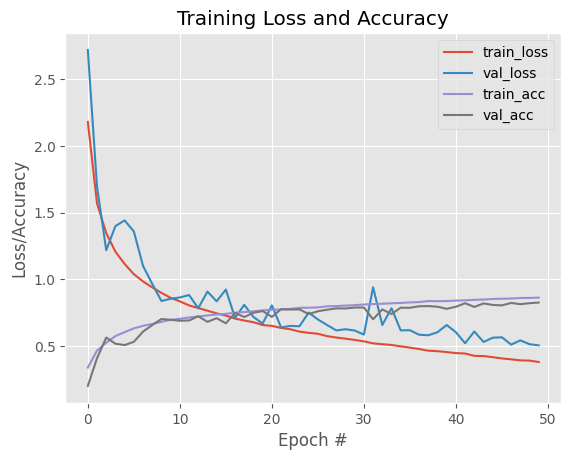

In [22]:

# Gráficas de evaluación durante el entrenamiento
plt.style.use("ggplot")
plt.figure()
plt.plot(np.arange(0, 50), H.history["loss"], label="train_loss")
plt.plot(np.arange(0, 50), H.history["val_loss"], label="val_loss")
plt.plot(np.arange(0, 50), H.history["accuracy"], label="train_acc")
plt.plot(np.arange(0, 50), H.history["val_accuracy"], label="val_acc")
plt.title("Training Loss and Accuracy")
plt.xlabel("Epoch #")
plt.ylabel("Loss/Accuracy")
plt.legend()
plt.show()

Resumen: Encontramos mayor accuracy y menor overfitting en comparacion de los otros entrenamientos